In [1]:
account_path = '/content/drive/MyDrive/'

# Mount & Import

In [2]:
# mount the drive
from google.colab import drive
drive.mount('/content/drive/')
from google.colab import auth
auth.authenticate_user()

# load packages - basics
!pip install pynrrd
import os
import csv
import numpy as np
import pandas as pd
import math
import time
import json
import nrrd
import pickle

Mounted at /content/drive/


In [3]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
from itertools import accumulate
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression, LinearRegression, LassoCV, RidgeCV, ElasticNet, ElasticNetCV

In [4]:
# load packages - stats
!pip install scikit-posthocs
import scipy
from scipy import io
from scipy.fftpack import rfft, irfft, fftfreq
import scipy.stats as stats

import statsmodels.api as sm
import statsmodels.formula.api as smf
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels

import random
from random import randrange, shuffle
import itertools
from itertools import combinations
import sklearn
from sklearn.decomposition import PCA, FastICA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score

In [5]:
# load packages - plotting and template settings
import matplotlib as mpl
from matplotlib import pyplot as plt
%matplotlib inline

from matplotlib.patches import Rectangle
import matplotlib.patches as patches
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib import animation
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [6]:
!pip install upsetplot
from upsetplot import plot, UpSet; from matplotlib import pyplot
from upsetplot import from_contents, from_indicators, from_memberships, generate_counts

def upset_df_conversion(overlap):
  """This script convert the response overlap profile into arrays
    cell_arr: cell_num x 1
    resp_arr: cell_num x n_stim
  """
  cell_ids = overlap.to_numpy(dtype=int)
  resps = overlap.index; resp = resps.to_numpy(dtype=list)

  cell_arr=[]; resp_arr=[]
  for cell, res in zip(cell_ids, resp):
    cell_arr.append(cell[0])
    lst = [t for t in res]
    resp_arr.append(lst)

  cell_arr=np.array(cell_arr)
  resp_arr=np.array(resp_arr)

  return cell_arr, resp_arr

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for upsetplot: filename=upsetplot-0.9.0-py3-none-any.whl size=24864 sha256=99427be07609eccad3cd7416865185a1e86b99ac60f6d77ed20ab60e0c2acc34
  Stored in directory: /root/.cache/pip/wheels/5d/7a/54/1460364da0fe4e17c256b7a28191fa373d81292fcf73a4ddb8
Successfully built upsetplot


## fcn

In [7]:
# load custom functions and sleap skeleton
%cd '/content/drive/MyDrive/Yu_escape_paper/Colab_github/src'
%run jy_utils.ipynb
sleap_nodes = ['le','re','fb','mb','rb','t1','t2','t3','tt'] # sleap_nodes_jy

/content/drive/MyDrive/Yu_escape_paper/Colab_github/src


# Experiment list (dots)

In [8]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1tpUkPiWTz_j2fthNLOIQvooPCbYnScKaoHLthi5yq18/edit?gid=106031496#gid=106031496'
tab_name = 'four_stim'

path = account_path + 'Yu_escape_paper/Imaging/Dots_do_stuff/'
data_path = path + 'Data/'
save_path = path + 'Analysis/'
figure_path = path + 'Figures/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index
fcn_files = metadata.fcn_file
planeNum = metadata.planeNum
trialNum = metadata.trialNum

,experiment,fcn_file,planeNum,ROI_csv,trialNum,atlas_1,atlas_2,
0,jy-241126-f2,t2-stimR,2,2,10 9 10 10,58-77,65-84,
1,jy-241126-f4,t1-stimL,2,2,6 6 5 6,69-62,81-76,
2,jy-241126-f4,t2-stimR,2,2,5 4 5 4,76-69,83-77,
3,jy-241126-f4,t3-stimL,2,2,4 4 4 4,68-60,80-73,
4,jy-241203-f2,t1-stimL,2,2,7 7 7 8,76-58,91-74,
5,jy-241203-f2,t2-stimR,2,2,8 9 8 9,78-60,98-80,
6,jy-241203-f2,t3-stimR,1,1,10 10 10 9,88-70,,
7,jy-241203-f3,t1-stimL,2,2,9 9 10 9,75-68,88-83,
8,jy-241203-f3,t2-stimR,2,2,10 10 10 10,77-71,86-80,good brain
9,jy-241203-f3,t3-stimL,1,1,8 8 9 8,72-66,,


## config

In [9]:
# brain regions - update this
forebrain_regions = ['forebrain','habenula']
visual_regions = ['tectum','pretectum','thalamus','hypothalamus']
hindbrain_regions = ['cerebellum']

regions_of_interest = [forebrain_regions, visual_regions, hindbrain_regions]

In [10]:
# establish stim type num, names, and colors
resample_Hz = 10
stim_names = ['Linear motion','Loom','Biological motion','Biological motion-escape']
stim_colorz = ["teal","purple","goldenrod","darkorange"]

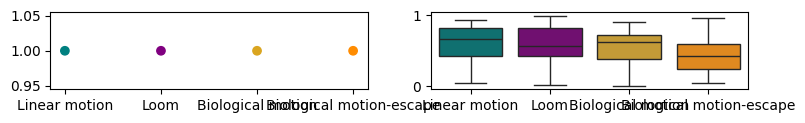

In [11]:
# RGB hex values theme - for summary stats plots
group_num = len(stim_names)
tmp = {n: np.random.random(20) for n in stim_names};
plt.figure(figsize=[9,1])
plt.subplot(121); plt.scatter(np.arange(group_num),np.ones(group_num),c=stim_colorz); plt.xticks(np.arange(group_num),stim_names);
plt.subplot(122); sns.boxplot(data=tmp,palette=stim_colorz); plt.show()

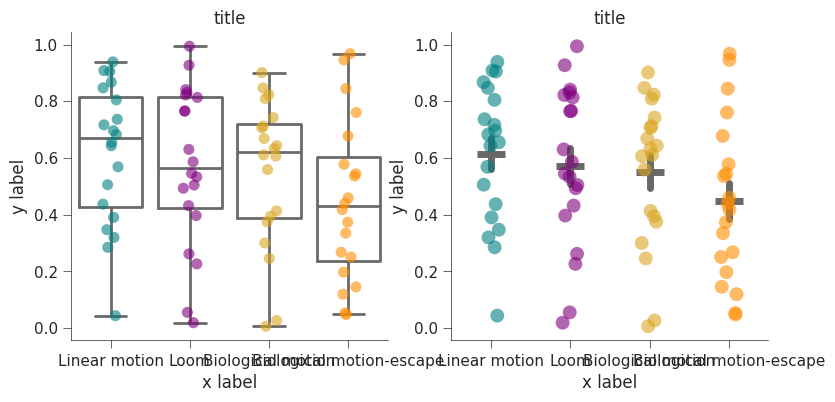

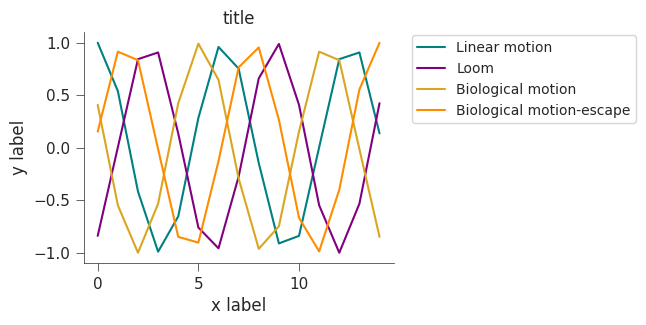

In [12]:
# figures output parameters
# figures output parameters
mpl.rcParams['lines.linewidth'] = 1        # default line width
mpl.rcParams['patch.linewidth'] = 0
mpl.rcParams['axes.spines.top'] = False
mpl.rcParams['axes.spines.right'] = False

# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)

mpl.rcParams['figure.figsize'] = (4,3)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 8        # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

mpl.rcParams['xtick.major.width'] = 0.5    # X-axis major tick width
mpl.rcParams['ytick.major.width'] = 0.5    # Y-axis major tick width
mpl.rcParams['axes.linewidth'] = 0.5       # Axis line width

from cycler import cycler
# remove red from the default colors
mpl.rcParams['axes.prop_cycle'] = cycler('color', ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf'])

# visualize to calibrate
plt.figure(figsize=[9,4]);
plt.subplot(121);
sns.boxplot(data=tmp,color='dimgrey',fill=False,linewidth=2);
sns.stripplot(data=tmp,palette=stim_colorz,alpha=0.6,size=8);
plt.title('title'); plt.xlabel('x label'); plt.ylabel('y label'); sns.despine();
plt.subplot(122);
sns.pointplot(data=tmp,color='dimgrey',linestyle="none",marker="_",errorbar='se',markersize=20,markeredgewidth=5,errwidth=5); #
sns.stripplot(data=tmp,palette=stim_colorz,alpha=0.6,size=10);
plt.title('title'); plt.xlabel('x label'); plt.ylabel('y label');
sns.despine(); #plt.show()

# plots with legends
plt.figure(figsize=[4,3])
tmp2 = [np.cos(np.arange(i*10,15+i*10)) for i in range(len(stim_names))]
for i in range(len(stim_names)):
  plt.plot(tmp2[i],label=stim_names[i],color=stim_colorz[i])
plt.legend(bbox_to_anchor=(1.05,1),markerscale=0.7,borderaxespad=0.2,fontsize=10)
plt.title('title'); plt.xlabel('x label'); plt.ylabel('y label');
sns.despine(); plt.show()

# Save out PSTHs

In [ ]:
# save all traces into psths
pre_stim_dur = 5*resample_Hz # (sec), bseline before stim onset
post_stim_dur = 20*resample_Hz # (sec), min. for 6-s stimulus + (14 to 16)-s interval
# trial_len = pre_stim_dur + 6*resample_Hz + post_stim_dur

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  figure_path = figure_path + exp + '/' + ffile + '/'

  # load processed 2p info
  data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
  traces_Z, xs, ys, zs = data['traces_Z'], data['xs'], data['ys'], data['zs']
  # load stimulus onsets
  with open(load_path+'stim_ON.pkl', 'rb') as f:
    stim_on = pickle.load(f) # len(stim_names) x [n for f in trial_num]

  # make nested list: cell_num x stim_type_num x trial_num (vary)
  PSTHs=[]
  for tr in traces_Z:
    psth=[]
    for st in stim_on: psth.append([tr[(i-pre_stim_dur):(i+post_stim_dur)] for i in st \
                 if i-pre_stim_dur>0 and (i+post_stim_dur) <len(tr)])
    PSTHs.append(psth)

  # SAVING
  os.makedirs(output_path, exist_ok=True)
  with open(output_path+'PSTHs.pkl', 'wb') as f:
    pickle.dump((PSTHs), f)
  print(f"{exp}: {ffile} PSTHs = {len(PSTHs)} cells, {[len(i) for i in PSTHs[0]]} trials")
  print([t1,t2,t3,t4]) # double-check metadata is correct

  # break

## save tail motion energy during PSTHs

In [ ]:
resample_Hz = 10

# save all traces into psths
pre_stim_dur = 5*resample_Hz # (sec), bseline before stim onset
post_stim_dur = 20*resample_Hz # (sec), min. for 6-s stimulus + (14 to 16)-s interval
# trial_len = pre_stim_dur + 6*resample_Hz + post_stim_dur

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  figure_path = figure_path + exp + '/' + ffile + '/'

  # load stimulus onsets
  with open(load_path+'stim_ON.pkl', 'rb') as f:
    stim_on = pickle.load(f) # len(stim_names) x [n for f in trial_num]
  # load stimulus
  data = np.load(load_path+'regressors.npz', allow_pickle=True)
  move = data['move']
  move = np.interp(np.arange(len(move)), np.flatnonzero(~np.isnan(move)), move[~np.isnan(move)]) # interpolate nan values

  s = pd.Series(move)
  baseline_window = 30 # sec
  r = s.rolling(window=resample_Hz * baseline_window, min_periods=int(resample_Hz * baseline_window / 2)) # take rolling window mean and std
  move_Z_1 = ((s - r.mean()) / r.std()).to_numpy() # take Z score of the motion energy
  move_Z_1 = np.nan_to_num(move_Z_1) # avoid nan values
  tail_move_1 = move_Z_1 > 2 # binary catergorize to if there's movement

  # make nested list: 1 (tail) x stim_type_num x trial_num (vary)
  move_PSTHs=[]
  for st in stim_on:
    move_PSTHs.append([move_Z_1[(i-pre_stim_dur):(i+post_stim_dur)] for i in st \
                 if i-pre_stim_dur>0 and (i+post_stim_dur) <len(move_Z_1)])

  # SAVING
  os.makedirs(output_path, exist_ok=True)
  with open(output_path+'tail_move_psths.pkl', 'wb') as f:
    pickle.dump((move_PSTHs), f)
  print(f"{exp}: {ffile} tail_Z scored PSTHs saved")
  # break

# Single neuron analysis

## t-test

In [ ]:
# save out metric & selection arrays
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'
  figure_path = figure_path + exp + '/' + ffile + '/'
  print("fish #", exp, ': ', ffile)
  # load PSTHs
  with open(output_path+'PSTHs.pkl', 'rb') as f:
    PSTHs = pickle.load(f) # cell_num x stim_types x x [trial_num for stim in stim_names]

  # go through each cell
  p_vals = [[] for n in range(len(stim_names))]
  p_vals_long = [[] for n in range(len(stim_names))]
  for cell_psth in PSTHs:
    # go through each stim type
    for id in range(len(stim_names)):
      base = [np.nanmean(x[0:pre]) for x in cell_psth[id]]
      resp = [np.nanmean(x[pre:pre+stim_dur]) for x in cell_psth[id]]
      _, p = stats.ttest_rel(base, resp);
      p_vals[id].append(p)

      resp_long = [np.nanmean(x[pre:pre+stim_dur+off]) for x in cell_psth[id]]
      _, p_long = stats.ttest_rel(base, resp_long);
      p_vals_long[id].append(p_long)

  p_vals = np.array(p_vals); p_vals_long = np.array(p_vals_long)
  # categorize responsive or not # use long window here
  all_profile = np.array([p<0.05 for p in p_vals_long]) # resp profile of all cells
  resp_arr = all_profile[:,np.any(all_profile,axis=0)] # resp profiles of all responsive cells
  # get cell ids
  resp_ids = [np.arange(p_vals_long.shape[1])[p<0.05] for p in p_vals_long];
  cell_arr = np.unique(np.concatenate(resp_ids)) # list of cell id resp to any stim

  # SAVING
  np.savez(output_path+'dF_ttest.npz',Pval=p_vals,Pval_long=p_vals_long)
  np.savez(output_path+'ttest_cells_long.npz',cell_id=cell_arr,resp_arr=resp_arr)

## pearson corr R

In [ ]:
# save out metric & selection arrays
pre, stim_dur, post = [sec*resample_Hz for sec in [5, 6, 14]] # baseline/stim on/ITI
off = 3*resample_Hz # potential response window to offset of stimulus

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  [t1, t2, t3, t4] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/'; output_path = save_path + exp + '/' + ffile + '/'

  print("fish #", exp, ': ', ffile)
  # load processed 2p info
  data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
  traces_Z = data['traces_Z']
  # load stimulus/behavior
  data = np.load(load_path+'regressors.npz', allow_pickle=True)
  stimuli, regressors = data['stimuli'], data['regressors']

  # go through each cell
  corr = [[] for n in range(len(stim_names))]
  for tr in traces_Z:
    # go through each stim type
    for id in range(len(stim_names)):
      r,p = scipy.stats.pearsonr(tr,regressors[id]) # Pearson correlation
      corr[id].append(r)

  corr = np.array(corr)
  # categorize responsive or not # use corr>0.
  all_profile = np.array([r>0.5 for r in corr]) # resp profile of all cells
  resp_arr = all_profile[:,np.any(all_profile,axis=0)] # resp profiles of all responsive cells
  # get cell ids
  resp_ids = [np.arange(corr.shape[1])[r>0.5] for r in corr];
  cell_arr = np.unique(np.concatenate(resp_ids)) # list of cell id resp to any stim

  # SAVING
  np.savez(output_path+'pearson_corr.npz',corr=corr)
  np.savez(output_path+'corr_cells_05.npz',cell_id=cell_arr,resp_arr=resp_arr)

# Experiments (Fish)

In [13]:
# directories for the data and analysis
gsheet = 'https://docs.google.com/spreadsheets/d/1tpUkPiWTz_j2fthNLOIQvooPCbYnScKaoHLthi5yq18/edit?gid=106031496#gid=106031496'
tab_name = 'fish_stim'

path = account_path + 'Yu_escape_paper/Imaging/Fish_do_stuff/'
data_path = path + 'Data/'
save_path = path + 'Analysis/'
figure_path = path + 'Figures/'

metadata = read_metadata(gsheet,tab_name)
experiments = metadata.index
fcn_files = metadata.fcn_file
planeNum = metadata.planeNum
trialNum = metadata.trialNum

,experiment,fcn_file,planeNum,trialNum
0,jy-260210-f1,t3-stimL_trim,1,4 4 4 3 4
1,jy-260210-f2,t3-stimR_trim,1,5 5 5 5 5
2,jy-260218-f1,t1-stimR_trim,1,5 6 5 6 7
3,jy-260218-f1,t2-stimR,1,10 10 10 10 10
4,jy-260218-f1,t3-stimR,1,10 10 10 10 10
5,jy-260218-f1,t4-stimR,1,10 10 10 10 10
6,jy-260218-f2,t1-stimL_trim,1,10 10 10 10 10
7,jy-260218-f2,t2-stimL,1,10 10 10 10 10
8,jy-260218-f2,t3-stimL,1,10 10 10 10 10
9,jy-260218-f2,t4-stimL,1,10 10 10 10 10


## config

In [14]:
# brain regions - update this
forebrain_regions = ['forebrain','habenula']
visual_regions = ['tectum','pretectum','thalamus','hypothalamus']
hindbrain_regions = ['cerebellum']

regions_of_interest = [forebrain_regions, visual_regions, hindbrain_regions]

In [15]:
# establish stim type num, names, and colors
resample_Hz = 10
stim_names = ['Biological motion-escape','Biological motion-disappear',\
              'Linear motion-escape','Linear motion-disappear','Biological motion-loom']
stim_colorz = ["darkorange","chocolate","mediumturquoise","teal","maroon"]

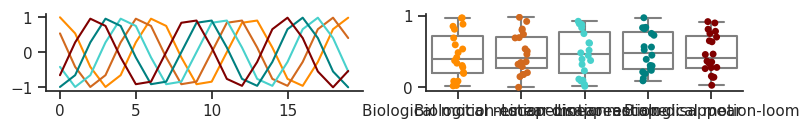

In [16]:
# figures output parameters
# Set global Matplotlib parameters for PDF output
mpl.rcParams['pdf.fonttype'] = 42          # Use TrueType fonts (editable text)
mpl.rcParams['svg.fonttype'] = 'none'      # Keeps text as editable text instead of converting to paths

mpl.rcParams['figure.figsize'] = (8,6)     # Default figure size in inches
mpl.rcParams['axes.titlesize'] = 16        # Title font size
mpl.rcParams['axes.labelsize'] = 14        # Axis label font size
mpl.rcParams['xtick.labelsize'] = 10       # X-axis tick label size
mpl.rcParams['ytick.labelsize'] = 10       # Y-axis tick label size
mpl.rcParams['legend.fontsize'] = 10       # Legend font size
mpl.rcParams['savefig.dpi'] = 300          # DPI for high-quality export (relevant for raster elements) (not crucial for SVG)
mpl.rcParams['savefig.transparent'] = True # Ensures background is transparent
sns.set(style="white",font_scale=1)     # global scaling of all texts
mpl.rcParams['xtick.bottom'] = True        # make sure ticks visible
mpl.rcParams['ytick.left'] = True

group_num = len(stim_names); group_names = stim_names
tmp = {n: np.random.random(20) for n in stim_names};

# validate colors settings work with both major plotting packages
plt.figure(figsize=[9,1]); plt.subplot(121);
for igs, gs in enumerate(group_names): plt.plot(np.cos(np.arange(igs,igs+20)),c=stim_colorz[igs]);
tmp = {n: np.random.random(20) for n in group_names};
plt.subplot(122); sns.boxplot(data=tmp,fill=False,color='gray'); sns.stripplot(data=tmp,palette=stim_colorz); sns.despine();
plt.show()

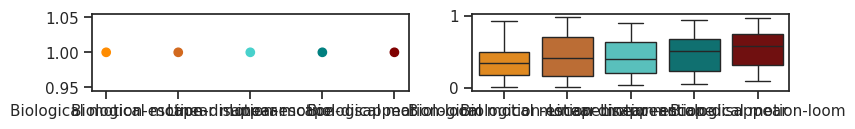

In [17]:
# RGB hex values theme - for summary stats plots
group_num = len(stim_names)
tmp = {n: np.random.random(20) for n in stim_names};
plt.figure(figsize=[9,1])
plt.subplot(121); plt.scatter(np.arange(group_num),np.ones(group_num),c=stim_colorz); plt.xticks(np.arange(group_num),stim_names);
plt.subplot(122); sns.boxplot(data=tmp,palette=stim_colorz); plt.show()

# Save out PSTHs

In [ ]:
# save all traces into psths
pre_stim_dur = 5*resample_Hz # (sec), bseline before stim onset
post_stim_dur = 20*resample_Hz # (sec), min. for 6-s stimulus + (14 to 16)-s interval
# trial_len = pre_stim_dur + 6*resample_Hz + post_stim_dur

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  [t1, t2, t3, t4, t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  figure_path = figure_path + exp + '/' + ffile + '/'

  # load processed 2p info
  data = np.load(load_path+'neuron_details.npz', allow_pickle=True)
  traces_Z, xs, ys, zs = data['traces_Z'], data['xs'], data['ys'], data['zs']
  # load stimulus onsets
  with open(load_path+'stim_ON.pkl', 'rb') as f:
    stim_on = pickle.load(f) # len(stim_names) x [n for f in trial_num]

  # make nested list: cell_num x stim_type_num x trial_num (vary)
  PSTHs=[]
  for tr in traces_Z:
    psth=[]
    for st in stim_on: psth.append([tr[(i-pre_stim_dur):(i+post_stim_dur)] for i in st \
                 if i-pre_stim_dur>0 and (i+post_stim_dur) <len(tr)])
    PSTHs.append(psth)

  # SAVING
  os.makedirs(output_path, exist_ok=True)
  with open(output_path+'PSTHs.pkl', 'wb') as f:
    pickle.dump((PSTHs), f)
  print(f"{exp}: {ffile} PSTHs = {len(PSTHs)} cells, {[len(i) for i in PSTHs[0]]} trials")
  print([t1,t2,t3,t4,t5]) # double-check metadata is correct

## save tail motion energy

In [ ]:
resample_Hz = 10

# save all traces into psths
pre_stim_dur = 5*resample_Hz # (sec), bseline before stim onset
post_stim_dur = 20*resample_Hz # (sec), min. for 6-s stimulus + (14 to 16)-s interval
# trial_len = pre_stim_dur + 6*resample_Hz + post_stim_dur

for exp, ffile, plane_num, trial_num in zip(experiments, fcn_files, planeNum, trialNum):
  [t1, t2, t3, t4, t5] = [int(t) for t in trial_num.split(' ')]
  load_path = data_path + exp + '/' + ffile + '/';
  output_path = save_path + exp + '/' + ffile + '/'
  figure_path = figure_path + exp + '/' + ffile + '/'

  # load stimulus onsets
  with open(load_path+'stim_ON.pkl', 'rb') as f:
    stim_on = pickle.load(f) # len(stim_names) x [n for f in trial_num]
  # load stimulus
  data = np.load(load_path+'regressors.npz', allow_pickle=True)
  move = data['move']
  move = np.interp(np.arange(len(move)), np.flatnonzero(~np.isnan(move)), move[~np.isnan(move)]) # interpolate nan values

  s = pd.Series(move)
  baseline_window = 30 # sec
  r = s.rolling(window=resample_Hz * baseline_window, min_periods=int(resample_Hz * baseline_window / 2)) # take rolling window mean and std
  move_Z_1 = ((s - r.mean()) / r.std()).to_numpy() # take Z score of the motion energy
  move_Z_1 = np.nan_to_num(move_Z_1) # avoid nan values
  tail_move_1 = move_Z_1 > 2 # binary catergorize to if there's movement

  # make nested list: 1 (tail) x stim_type_num x trial_num (vary)
  move_PSTHs=[]
  for st in stim_on:
    move_PSTHs.append([move_Z_1[(i-pre_stim_dur):(i+post_stim_dur)] for i in st \
                 if i-pre_stim_dur>0 and (i+post_stim_dur) <len(move_Z_1)])

  # SAVING
  os.makedirs(output_path, exist_ok=True)
  with open(output_path+'tail_move_psths.pkl', 'wb') as f:
    pickle.dump((move_PSTHs), f)
  print(f"{exp}: {ffile} tail_Z scored PSTHs saved")

# Single neuron analysis

## t-test

In [ ]:
# find cells whose F during stim vs baseline is <.05 in t-test # one-tailed (excitatory)
# save the p-values into npz
stim_dur = 6*resample_Hz
pre_stim_dur = 5*resample_Hz # in sec, window size of interest before onset of stim
post_stim_dur = 8*resample_Hz # in sec, window size of interest after onset of stim

for exp, ffile, z in zip(experiments[:], fcn_files[:], planeNum[:]):
  print("subject #", exp, ':', ffile)
  zsteps = int(z)
  home_path = data_path + exp + '/' + ffile + '/'
  output_path = save_path + exp + '/' + ffile + '/'

  # load processed 2p
  data = np.load(home_path+'neuron_details.npz', allow_pickle=True)
  traces_Z, xs, ys, zs = data['traces_Z'], data['xs'], data['ys'], data['zs']
  # load stimulus onsets
  with open(home_path+'/stim_ON.pkl', 'rb') as f:
    stim_on = pickle.load(f)
  #
  Pval = [[] for i in range(len(stim_names))]
  # s1_r=[]; s2_r=[]; s3_r=[]; s4_r=[];
  stim_resp = [[] for i in range(len(stim_names))]

  # go through each cell
  for tr in traces_Z:

    # do the statistics
    pval=[]; resp=[]

    for id, stim in enumerate(stim_on):
      # get the mean responses difference
      tmp = [(np.mean(tr[onset:onset+post_stim_dur])-np.mean(tr[onset-pre_stim_dur:onset])) for onset in stim\
             if onset-pre_stim_dur>0 and onset+post_stim_dur<len(tr)]
      resp.append(np.mean(tmp))
      stim_resp[id].append(np.mean(tmp))
      # run t-test btw post stim and baseline
      _, p_value = stats.ttest_rel([np.mean(tr[onset:onset+post_stim_dur]) for onset in stim if onset-pre_stim_dur>0 and onset+post_stim_dur<len(tr)], \
       [np.mean(tr[onset-pre_stim_dur:onset]) for onset in stim if onset-pre_stim_dur>0 and onset+post_stim_dur<len(tr)])
      pval.append(p_value)
      Pval[id].append(p_value)

  Pval = np.array(Pval)
  # categorize responsive or not # use long window here
  all_profile = np.array([p<0.05 for p in Pval]) # resp profile of all cells
  resp_arr = all_profile[:,np.any(all_profile,axis=0)] # resp profiles of all responsive cells
  # get cell ids
  resp_ids = [np.arange(Pval.shape[1])[p<0.05] for p in Pval];
  cell_arr = np.unique(np.concatenate(resp_ids)) # list of cell id resp to any stim

  # save and summarize for the exp
  np.savez(output_path +'ttest_5-8.npz', Pval = Pval) # 5-sec baseline vs 10-sec stim ON
  np.savez(output_path+'ttest_5-8_cells.npz',cell_id=cell_arr,resp_arr=resp_arr)

## pearson corr

In [ ]:
# save the correlation coefiicients into npz

for exp, ffile, z in zip(experiments[:], fcn_files[:], planeNum[:]):
  print("subject #", exp, ':', ffile)
  zsteps = int(z)
  home_path = data_path + exp + '/' + ffile + '/'
  output_path = save_path + exp + '/' + ffile + '/'

  # load processed 2p
  data = np.load(home_path+'neuron_details.npz', allow_pickle=True)
  traces_Z, xs, ys, zs = data['traces_Z'], data['xs'], data['ys'], data['zs']
  # load stimulus onsets
  with open(home_path+'/stim_ON.pkl', 'rb') as f:
    stim_on = pickle.load(f)
  # load stimulus/behavior
  data = np.load(home_path+'/regressors.npz', allow_pickle=True)
  stimuli, regressors = data['stimuli'], data['regressors']

  #
  CORR = [ [] for i in range(len(stim_names))]
  # corr75 = [ 0 for i in range(len(stim_names))]; corr50 = [ 0 for i in range(len(stim_names))]

  # go through each cell
  for tr in traces_Z:
    for id in range(len((stim_names))): # loop through stimlus type
      # Pearson correlation
      r,p = scipy.stats.pearsonr(tr,regressors[id])
      CORR[id].append(r)

  # save and summarize for the exp
  np.savez(output_path +'corrcoeff.npz', corr = CORR)